<a href="https://colab.research.google.com/github/Kkurzo/-labs/blob/main/%D0%9B%D0%A03_%D0%9C%D0%B5%D0%BB%D1%8C%D0%BD%D0%B8%D1%87%D1%83%D0%BA_%D0%A4%D0%86%D0%A24_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна робота 3. Машинне навчання
## Регресія: прогнозування вартості нерухомості

**Мета роботи:** виконати первинний аналіз даних, побудувати кілька моделей регресії, оцінити їхню якість та виконати підбір гіперпараметрів для моделі Random Forest.

### Датасет
Можна використати один із двох способів завантаження даних:

1. Завантажити файл з Google Drive:
https://drive.google.com/file/d/1u_-3X05st6uvrgQB1qNLyE8a7QjTJjvd/view?usp=sharing

2. Завантажити датасет з Kaggle:
https://www.kaggle.com/datasets/prokshitha/home-value-insights

> Посилання та вміст датасету на зовнішніх платформах можуть змінюватися.

## 1. Імпорт бібліотек
Імпортуйте бібліотеки, необхідні для роботи з даними, візуалізації та числових обчислень.

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd



## 2. Завантаження даних
Оберіть **один** зі способів завантаження датасету.

### Варіант 1. Завантаження файлу з комп’ютера
Завантажте CSV-файл у середовище Colab.

In [70]:
from google.colab import files
uploaded = files.upload()




Saving house_price_regression_dataset.csv to house_price_regression_dataset (2).csv


### Варіант 2. Завантаження датасету з Kaggle
Завантажте датасет безпосередньо з Kaggle та прочитайте CSV-файл у DataFrame `df`.

In [71]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("prokshitha/home-value-insights")

print("Path to dataset files:", path)






Using Colab cache for faster access to the 'home-value-insights' dataset.
Path to dataset files: /kaggle/input/home-value-insights


## 3. Опис ознак датасету

**Площа:** Розмір будинку в квадратних футах. Більші будинки зазвичай мають вищі ціни.

**Num_Bedrooms:** Кількість спалень у будинку. Більша кількість спалень, як правило, збільшує вартість будинку.

**Num_Bathrooms:** Кількість ванних кімнат у будинку. Будинки з більшою кількістю ванних кімнат зазвичай коштують дорожче.

**Рік побудови:** Рік побудови будинку. Ціна на старі будинки може бути нижчою через знос.

**Розмір_лота:** Розмір ділянки, на якій побудовано будинок, вимірюється в акрах. Більші ділянки, як правило, підвищують вартість нерухомості.

**Розмір_гаражу:** Кількість автомобілів, які можуть поміститися в гаражі. Будинки з більшими гаражами зазвичай дорожчі.

**Якість_району:** Оцінка якості району за шкалою від 1 до 10, де 10 означає високоякісний район. Кращі райони зазвичай мають вищі ціни.

**Ціна_будинку** (цільова змінна): ціна будинку, яка є залежною змінною, яку ви прагнете передбачити.

## 4. Первинний аналіз даних

### Завдання 1. Перегляд даних
Виведіть перші рядки датасету та перегляньте його структуру.

In [72]:
df = pd.read_csv(os.path.join(path,"house_price_regression_dataset.csv"))
df.head()




,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


### Завдання 2. Перевірка дублікатів
Визначте кількість дубльованих рядків.

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [74]:
df.duplicated().sum()





np.int64(0)

### Завдання 3. Перевірка пропущених значень
Визначте кількість пропущених значень у кожному стовпці.

In [75]:
df.isnull().sum()





,0
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


### Завдання 4. Описова статистика
Виведіть основні статистичні характеристики числових ознак.

In [76]:
df.describe()





,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


## 5. Аналіз окремих ознак

### Завдання 5. Ознака `Neighborhood_Quality`
Виведіть частоти значень ознаки `Neighborhood_Quality`.

In [77]:
df["Neighborhood_Quality"].value_counts()


,count
Neighborhood_Quality,
10,123
5,109
2,105
7,102
6,101
4,99
8,97
1,91
9,88


### Завдання 6. Візуалізація `Neighborhood_Quality`
Побудуйте діаграму розподілу значень цієї ознаки.

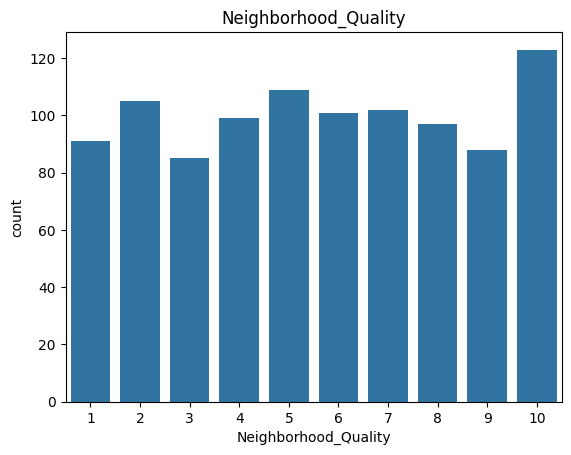

In [78]:
sns.countplot(x="Neighborhood_Quality", data=df)
plt.title("Neighborhood_Quality")
plt.show()




### Завдання 7. Ознака `Num_Bathrooms`
Виведіть частоти значень кількості ванних кімнат.

In [79]:
df["Num_Bathrooms"].value_counts()




,count
Num_Bathrooms,
1,350
2,327
3,323


### Завдання 8. Візуалізація `Num_Bathrooms`
Побудуйте діаграму розподілу кількості ванних кімнат.

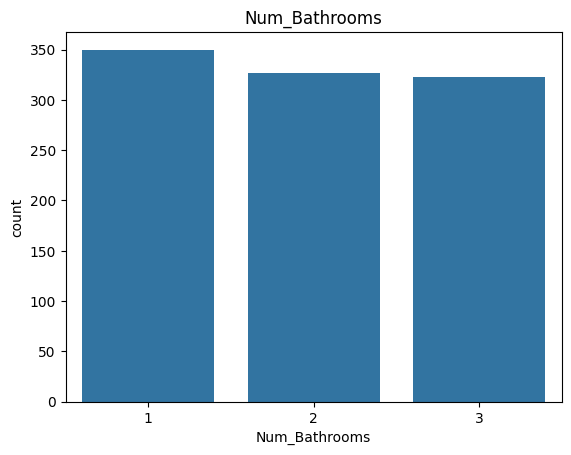

In [80]:
sns.countplot(x="Num_Bathrooms", data=df)
plt.title("Num_Bathrooms")
plt.show()





In [81]:
df["Num_Bedrooms"].value_counts()

,count
Num_Bedrooms,
2,215
5,205
1,201
4,197
3,182


### Додаткове завдання
За потреби побудуйте попарні графіки числових ознак і коротко проаналізуйте можливі залежності.

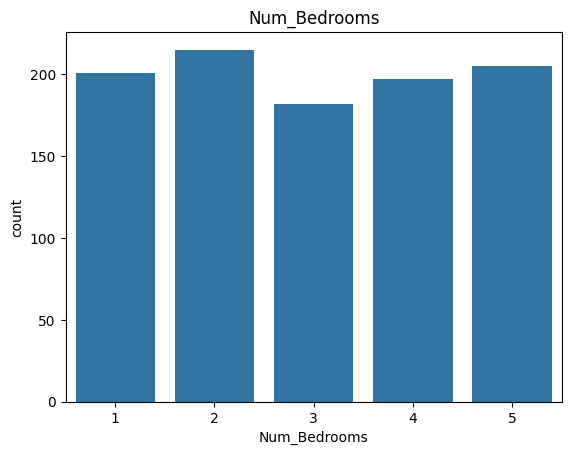

In [82]:
sns.countplot(x="Num_Bedrooms", data=df)
plt.title("Num_Bedrooms")
plt.show()



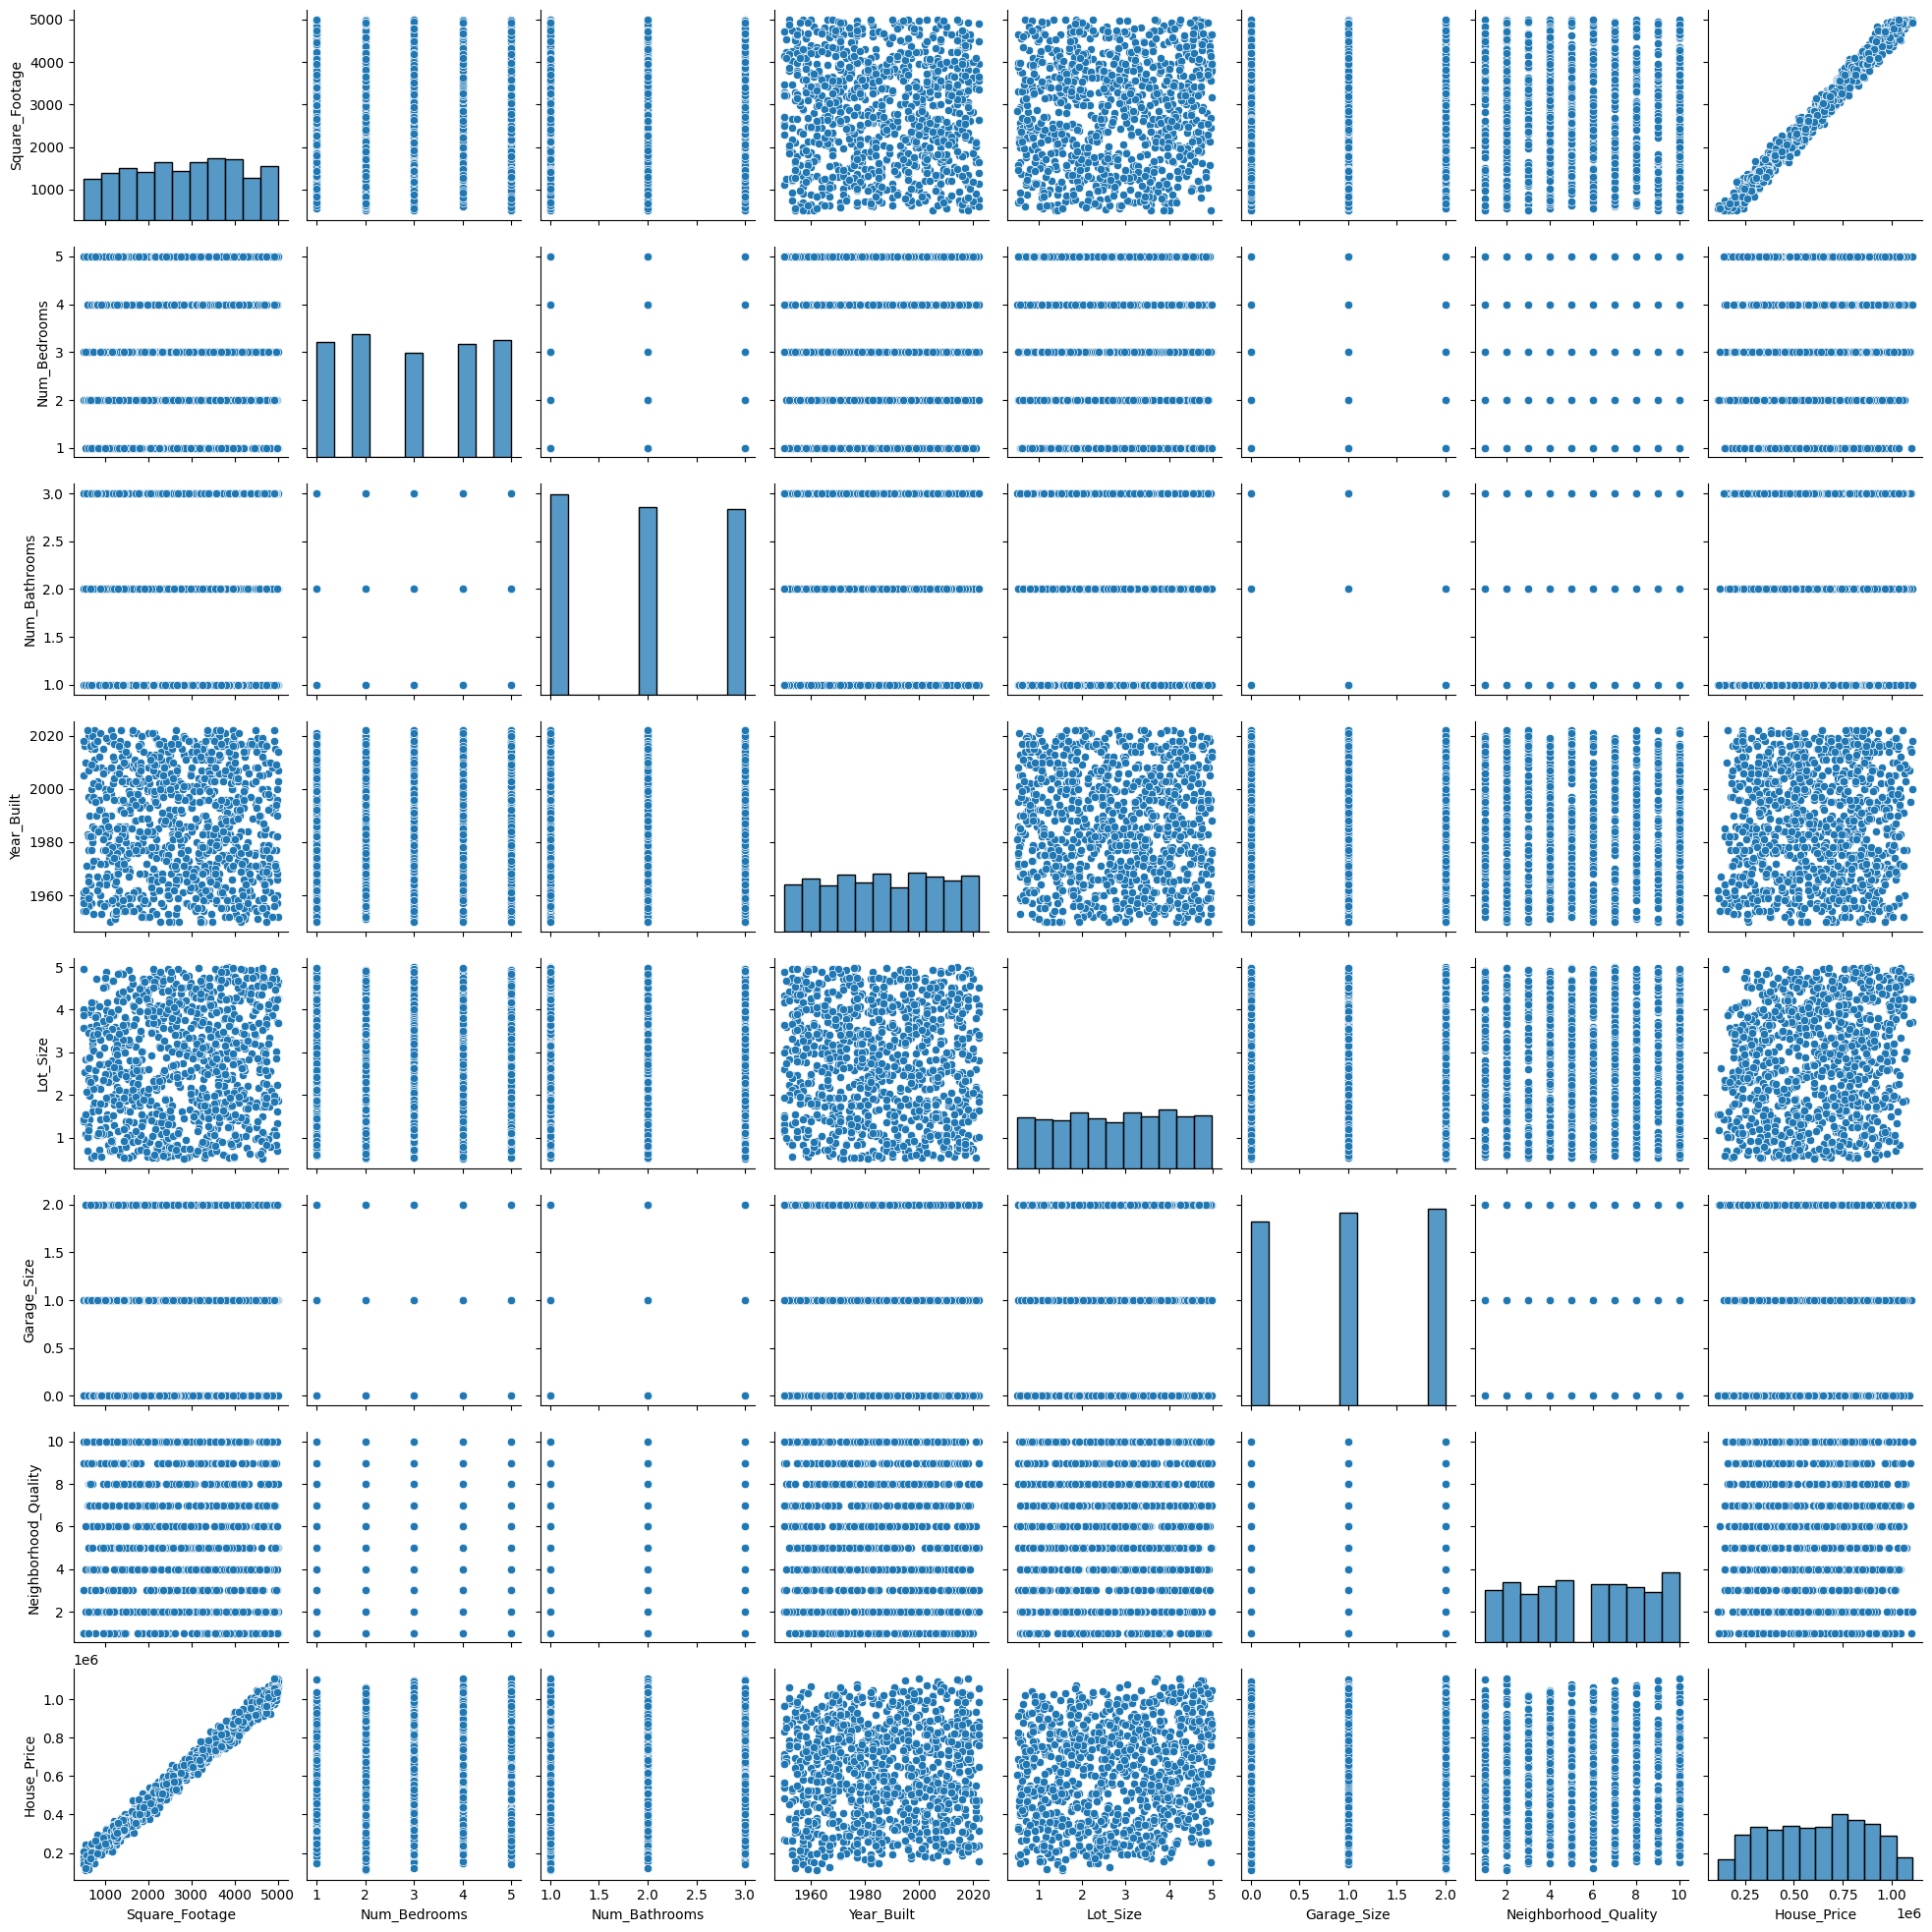

In [83]:
sns.pairplot(df)

## 6. Кореляційний аналіз

### Завдання 9. Матриця кореляції
Побудуйте кореляційну матрицю для числових ознак та відобразіть її у вигляді теплової карти.

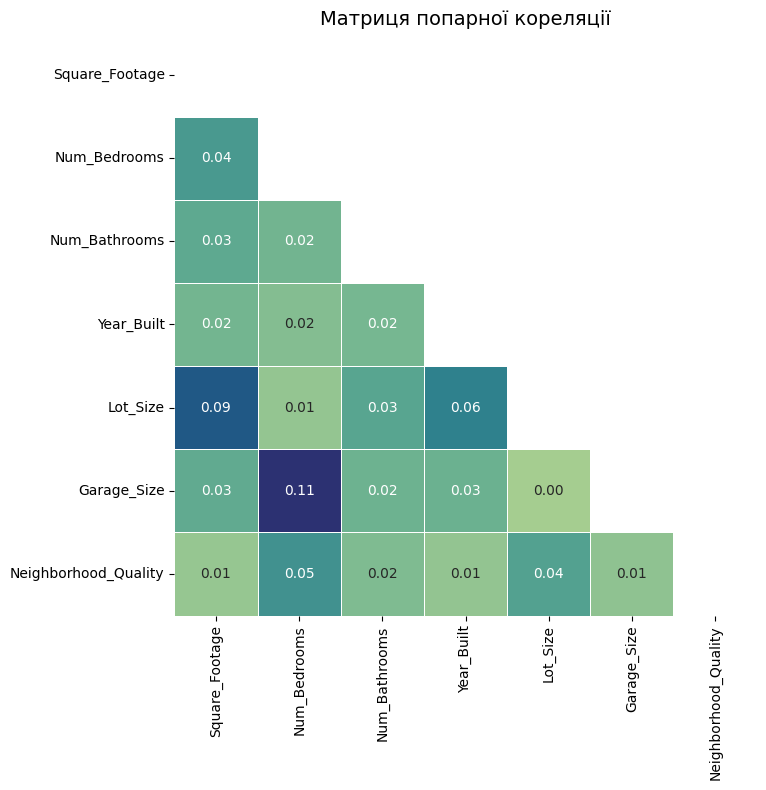

In [87]:
mtx = df.drop("House_Price", axis=1).corr(numeric_only=True).abs()
fig, ax = plt.subplots(figsize=(8,8))
sns.heatmap(
    mtx,
    cmap="crest",
    annot=True,
    fmt =".2f",
    linewidths=0.5,
    mask=np.triu(np.ones_like(mtx, dtype=bool)),
    square=True,
    cbar=False,
    ax=ax
)
plt.title("Матриця попарної кореляції", fontsize =14)
plt.tight_layout()
plt.show()




### Завдання 10. Кореляція з цільовою змінною
Виведіть кореляцію кожної ознаки з `House_Price`, відсортувавши значення за спаданням.

In [90]:
correlation_matrix = df.corr(numeric_only=True)
correlation_with_House_Price = correlation_matrix["House_Price"].sort_values(ascending=False)
correlation_with_House_Price




,House_Price
House_Price,1.000000
Square_Footage,0.991261
Lot_Size,0.160412
Garage_Size,0.052133
Year_Built,0.051967
Num_Bedrooms,0.014633
Num_Bathrooms,-0.001862
Neighborhood_Quality,-0.007770


## 7. Побудова моделей регресії

### Завдання 11. Імпорт інструментів Scikit-learn
Імпортуйте засоби для:
- поділу вибірки;
- масштабування ознак;
- побудови Linear Regression, Ridge, Lasso, Random Forest та Gradient Boosting;
- створення Pipeline;
- обчислення R², MAE та MSE.

In [149]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline



### Завдання 12. Формування `X` і `y`
Відокремте ознаки від цільової змінної `House_Price`.

In [150]:
X = df.drop(columns=["House_Price"])
y = df["House_Price"]




### Завдання 13. Поділ даних
Поділіть дані на навчальну і тестову вибірки у співвідношенні 80/20. Для відтворюваності використайте `random_state=42`.

In [151]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
  )





### Завдання 14. Створення моделей
Створіть п’ять моделей:
1. Linear Regression;
2. Ridge;
3. Lasso;
4. Random Forest Regressor;
5. Gradient Boosting Regressor.

Для лінійних моделей використайте `Pipeline` зі `StandardScaler`. Для деревоподібних моделей масштабування не потрібне.

In [152]:
models = {
    "LinerRegression": Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
    ]),
    "Ridge": Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
    ]),
    "Lasso": Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.1, max_iter=10000))
    ]),
    "Random Forest": RandomForestRegressor(
        random_state=42
        ),
    "Gradient  Boosting": GradientBoostingRegressor(
        random_state=42
    )
}




### Завдання 15. Навчання та оцінювання моделей
Для кожної моделі:
- виконайте навчання на тренувальній вибірці;
- отримайте прогноз для тестової вибірки;
- обчисліть `R²`, `MAE`, `MSE`;
- збережіть результати для подальшого порівняння.

In [153]:
result = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    result[name] = {
        "model": model,
        "y_pred": y_pred,
        "R2": r2,
        "MAE": mae,
        "MSE": mse
    }
    print(
    f"[{name}]"
    f"R2: {r2:.6f}"
    f"MAE: {mae:.3f}"
    f"MSE: {mse:.3f}"
)

[LinerRegression]R2: 0.998426MAE: 8174.584MSE: 101434798.506
[Ridge]R2: 0.998410MAE: 8241.587MSE: 102480990.009
[Lasso]R2: 0.998426MAE: 8174.607MSE: 101435077.051
[Random Forest]R2: 0.993886MAE: 16114.290MSE: 394131747.446
[Gradient  Boosting]R2: 0.996510MAE: 12305.218MSE: 224965597.845


### Завдання 16. Графічне порівняння прогнозів
Для кожної моделі побудуйте графік **фактичні значення vs прогнозовані значення**. Додайте лінію ідеального прогнозу.

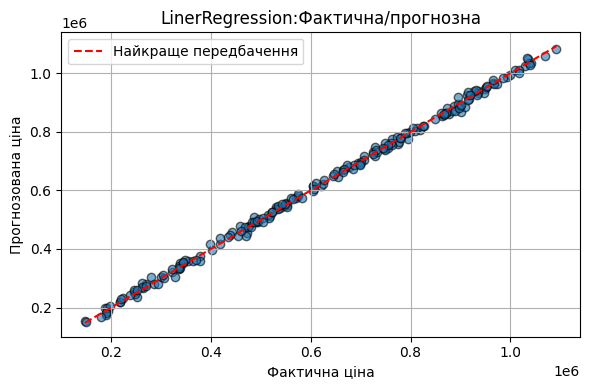

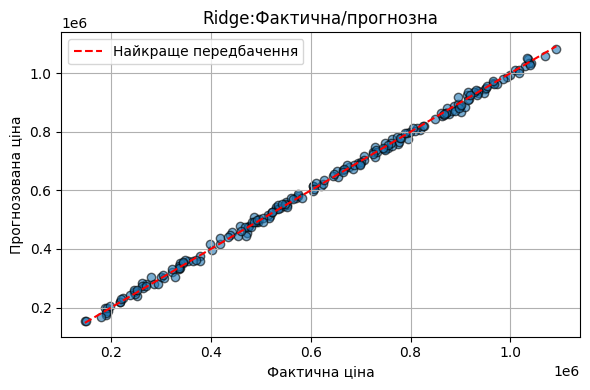

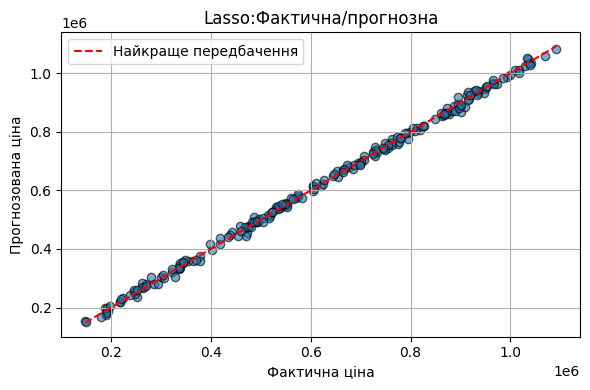

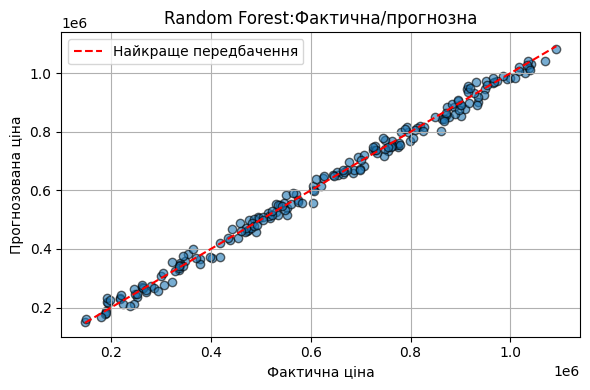

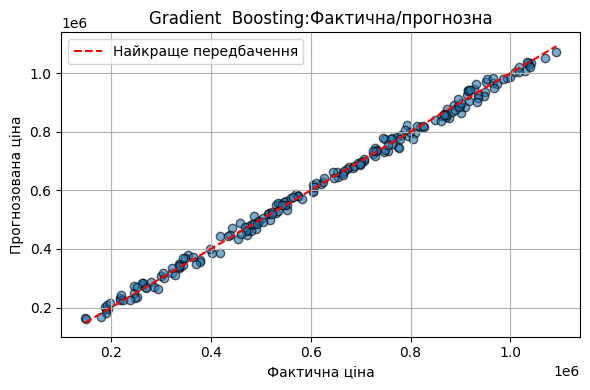

In [154]:
for name, res in result.items():
  plt.figure(figsize=(6, 4))
  plt.scatter(y_test, res["y_pred"], alpha=0.6, edgecolors="k")
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
           "r--", label="Найкраще передбачення")
  plt.xlabel("Фактична ціна")
  plt.ylabel("Прогнозована ціна")
  plt.title(f"{name}:Фактична/прогнозна")
  plt.legend()
  plt.grid(True)
  plt.tight_layout()
  plt.show()





## 8. Підбір гіперпараметрів Random Forest

### Завдання 17. GridSearchCV
Виконайте підбір оптимальних параметрів для `RandomForestRegressor` за допомогою `GridSearchCV`.

Дослідіть щонайменше такі параметри:
- `n_estimators`;
- `max_features`;
- `max_depth`;
- `min_samples_split`.

Використайте крос-валідацію та метрику `R²`.

In [155]:
from sklearn.model_selection import GridSearchCV

param_rf = {
    "n_estimators": [50, 100, 200],
    "max_features": ["sqrt", "log2", None],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10]
}

rf_reg_gs = RandomForestRegressor(random_state=42)
rf_search = GridSearchCV(
    estimator=rf_reg_gs,
    param_grid=param_rf,
    cv=5,
    scoring="r2",
    n_jobs=-1
)
rf_search.fit(X_train, y_train)

best_rf_params = rf_search.best_params_

print("Найкращі параметри:")
print(best_rf_params)




Найкращі параметри:
{'max_depth': None, 'max_features': None, 'min_samples_split': 2, 'n_estimators': 200}


### Завдання 18. Оптимізована модель Random Forest
Створіть нову модель з найкращими параметрами, навчіть її та обчисліть `R²`, `MAE`, `MSE` на тестовій вибірці.

In [156]:
rf_optimal = RandomForestRegressor(
    **best_rf_params,
    random_state=42
)

rf_optimal.fit(X_train, y_train)

y_pred = rf_optimal.predict(X_test)

rf_mse = mean_squared_error(y_test, y_pred)
rf_mae = mean_absolute_error(y_test, y_pred)
rf_r2 = r2_score(y_test, y_pred)
print(f"MSE: {rf_mse:.3f}")
print(f"MAE: {rf_mae:.3f}")
print(f"R2: {rf_r2:.6f}")





MSE: 387229091.921
MAE: 16035.168
R2: 0.993993


### Завдання 19. Порівняння Random Forest до і після оптимізації
Порівняйте значення `R²`, `MAE` і `MSE` для базової та оптимізованої моделей.

In [157]:
print("Random Forest:")
print(f"R2: {result['Random Forest']['R2']:.6f}")
print(f"MAE: {result['Random Forest']['MAE']:.3f}")
print(f"MSE: {result['Random Forest']['MSE']:.3f}")

print("\nRandom Forest (оптимізована):")
print(f"R2: {rf_r2:.6f}")
print(f"MAE: {rf_mae:.3f}")
print(f"MSE: {rf_mse:.3f}")




Random Forest:
R2: 0.993886
MAE: 16114.290
MSE: 394131747.446

Random Forest (оптимізована):
R2: 0.993993
MAE: 16035.168
MSE: 387229091.921


### Завдання 20. Аналіз оптимізації
Зробіть короткий висновок:
- чи покращилася якість моделі після підбору параметрів;
- які метрики змінилися;
- чи доцільно використовувати оптимізовану модель.

**Ваш висновок:**

Після підбору параметрів якість моделі Random Forest покращилася. Це можна визначити за зміною основних метрик: коефіцієнт детермінації R² збільшився, а значення MAE та MSE зменшилися порівняно з початковою моделлю.

## 9. Аналіз прогнозів лінійної регресії

### Завдання 21. Таблиця прогнозів
Для моделі Linear Regression створіть таблицю з трьома стовпцями:
- фактична ціна;
- прогнозована ціна;
- похибка у відсотках.

Виведіть 10 випадкових рядків.

In [159]:
linreg_pred = result["LinerRegression"]["y_pred"]
comparison_df = pd.DataFrame({
    "Фактична ціна": y_test.values,
    "Прогнозована ціна": linreg_pred,
})
comparison_df["Похибка у відсотках"] = (np.abs(comparison_df["Фактична ціна"] - comparison_df["Прогнозована ціна"]) / comparison_df["Фактична ціна"]) * 100
sample = comparison_df.sample(10, random_state=42)
print(sample.round(2))


     Фактична ціна  Прогнозована ціна  Похибка у відсотках
95      1068538.11         1059729.02                 0.82
15       194353.74          187868.55                 3.34
30       270230.64          279715.82                 3.51
158      986006.86          981949.27                 0.41
128      953339.73          957382.95                 0.42
115      914555.75          909764.27                 0.52
69       746167.73          742469.14                 0.50
170      646766.29          654445.55                 1.19
174      523323.07          524605.44                 0.25
45      1008539.16         1011343.64                 0.28


## 10. Висновки
Сформулюйте загальний висновок за результатами лабораторної роботи. Вкажіть:

1. Які моделі було побудовано.
2. Яка модель показала найкращі значення метрик.
3. Як вплинув підбір гіперпараметрів Random Forest.
4. Наскільки точними є прогнози на тестовій вибірці.
5. Які фактори можуть впливати на якість прогнозування ціни нерухомості.

**Загальний висновок:**